# Project 3 Assignment

## Assignment Overview & Instructions

The objective of project 3 is to perform keyword network analysis and word frequency
analysis.  
Please complete the following 7 tasks in this assessment, using the instructions indicated below.   

**Note:** You may create your own custom functions if necessary to complete the tasks.

### Task 1: Import the Dataset for use in your Notebook.   

You can find the source dataset [here](https://drive.google.com/file/d/1YJe45YXo0xSkFClGPBhKYLzupFEyGadK/view?usp=sharing)

In [10]:
## YOUR CODE HERE

import pandas as pd
df = pd.read_csv("keywords_data.csv")
df.head()

,Title,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10,Keyword 11,Keyword 12
0,Feb/03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meta-Analyses of Financial Performance and Equ...,EQUITY,ORGANIZATIONAL sociology,PERFORMANCE,META-analysis,PSYCHOMETRICS,ORGANIZATIONAL research,FINANCIAL performance,AGENCY theory,ORGANIZATIONAL effectiveness,ORGANIZATIONAL behavior,CORPORATE governance,NaN
3,"Home Country Environments, Corporate Diversifi...",DIVERSIFICATION in industry,BUSINESS planning,PERFORMANCE standards,EMPLOYEES -- Rating of,CORPORATE culture,STRATEGIC planning,ORGANIZATIONAL effectiveness,MANAGEMENT science,MANAGEMENT research,PRODUCT management,NaN,NaN
4,Safeguarding Investments in Asymmetric Interor...,INTERORGANIZATIONAL relations,INTERGROUP relations,BUSINESS communication,INVESTMENTS,SUPPLY chains,KNOWLEDGE management,INTERORGANIZATIONAL networks,CORPORATE governance,GROUP decision making,INTELLECTUAL capital,NaN,NaN


### **Task 2:**  Write a Python code to extract keyword data from the above file. 
Write a Python code to extract keyword data from the above file and convert it to a weighted adjacency matrix. See the figure below to understand the process

![Task Two - Adjacency matrix](Task%202%20-%20Figure%201.png)

In [2]:
## YOUR CODE HERE

# Extract keyword columns and select columns: Keyword 1 to Keyword 12
keyword_cols = [f'Keyword {i}' for i in range(1, 13)]
keyword_df = df[keyword_cols].dropna(how='all')


# Preprocess keyword :Convert keywords to lowercase, remove spaces and collect all keywords which can be considerd as token
all_docs_keywords = []
for _, row in keyword_df.iterrows():
    keywords = row.dropna().astype(str).str.lower().str.strip().tolist()

    
    if keywords:
        all_docs_keywords.append(keywords) # Only keep rows that have at least one keyword

# Generate Co-Occurence pairs
co_occurrence_pairs = []

for tokens in all_docs_keywords:
    filtered_tokens = sorted(set(tokens))  # This removes duplicates
    
    for i in range(len(filtered_tokens)):
        for j in range(len(filtered_tokens)):
            if i != j:
                co_occurrence_pairs.append((filtered_tokens[i], filtered_tokens[j]))
print(co_occurrence_pairs[:50])

# Converting pairs into DataFrame
pairs_df = pd.DataFrame(co_occurrence_pairs, columns=['Keyword1', 'Keyword2'])

# Creating adjacency matrix using crosstab
adjacency_matrix = pd.crosstab(pairs_df['Keyword1'], pairs_df['Keyword2'])

# Checking if matrix is symmetric or not
is_symmetric = (adjacency_matrix.values == adjacency_matrix.T.values).all()

print(f"Is adjacency matrix symmetric? {is_symmetric}")

print("\nAdjacency Matrix (First 10 rows):")
adjacency_matrix.head(10)

[('agency theory', 'corporate governance'), ('agency theory', 'equity'), ('agency theory', 'financial performance'), ('agency theory', 'meta-analysis'), ('agency theory', 'organizational behavior'), ('agency theory', 'organizational effectiveness'), ('agency theory', 'organizational research'), ('agency theory', 'organizational sociology'), ('agency theory', 'performance'), ('agency theory', 'psychometrics'), ('corporate governance', 'agency theory'), ('corporate governance', 'equity'), ('corporate governance', 'financial performance'), ('corporate governance', 'meta-analysis'), ('corporate governance', 'organizational behavior'), ('corporate governance', 'organizational effectiveness'), ('corporate governance', 'organizational research'), ('corporate governance', 'organizational sociology'), ('corporate governance', 'performance'), ('corporate governance', 'psychometrics'), ('equity', 'agency theory'), ('equity', 'corporate governance'), ('equity', 'financial performance'), ('equity',

Keyword2,agency theory,aggression (psychology),ambivalence,anger in the workplace,behavioral research,boards of directors,break-even analysis,burnout (psychology),business communication,business enterprises,...,violence in the workplace,wage payment systems,wages,women -- employment,women employees,work & family,work attitudes,work environment,work environment -- psychological aspects,workflow
Keyword1,,,,,,,,,,,,,,,,,,,,,
agency theory,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aggression (psychology),0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,2,0,0
ambivalence,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anger in the workplace,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
behavioral research,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
boards of directors,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
break-even analysis,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
burnout (psychology),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
business communication,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Task 3:**  Read the adjacency matrix and convert it into a weighted network

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Build the weighted co-cocurrence network
graph = nx.from_pandas_adjacency(adjacency_matrix)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 248
Edges: 2141


### **Task 4:**  Compute node degree and strength

In [6]:
# Degree: number of neighbors
degree_df = dict(graph.degree())

# Strength:sum of edge weights
strength_df = dict(graph.degree(weight="weight"))
# Convert to DataFrame for better analysis
metrics_df = pd.DataFrame({
    "Keyword": list(degree_df.keys()),
    "Degree": list(degree_df.values()),
    "Strength": [strength_df[k] for k in degree_df.keys()]
})

print("Top Keywords by Strength:")
display(metrics_df.head(10))

Top Keywords by Strength:


,Keyword,Degree,Strength
0,agency theory,38,48
1,aggression (psychology),18,20
2,ambivalence,9,9
3,anger in the workplace,11,11
4,behavioral research,9,9
5,boards of directors,21,21
6,break-even analysis,11,11
7,burnout (psychology),11,11
8,business communication,9,9
9,business enterprises,9,9


### **Task 5:**  Show the top 10 nodes by degree and top 10 nodes by strength

In [7]:
# Display Top 10 by Degree
top_degree = metrics_df.sort_values(by="Degree", ascending=False).head(10)
print("Top 10 Keywords by Degree:")
display(top_degree)
# Display Top 10 by Strength
top_strength = metrics_df.sort_values(by="Strength", ascending=False).head(10)
print("Top 10 Keywords by Strength:")
display(top_strength)

Top 10 Keywords by Degree:


,Keyword,Degree,Strength
154,organizational behavior,166,265
157,organizational effectiveness,104,144
135,management science,102,136
169,personnel management,93,126
47,decision making,90,112
162,organizational structure,74,107
161,organizational sociology,66,96
220,strategic planning,66,80
99,industrial management,64,84
28,corporate governance,62,85


Top 10 Keywords by Strength:


,Keyword,Degree,Strength
154,organizational behavior,166,265
157,organizational effectiveness,104,144
135,management science,102,136
169,personnel management,93,126
47,decision making,90,112
162,organizational structure,74,107
161,organizational sociology,66,96
28,corporate governance,62,85
99,industrial management,64,84
220,strategic planning,66,80


### **Task 6:** Show the top 10 node pairs by weight

In [8]:
# Extract unique edges with their weights(undirected)
edges = nx.to_pandas_edgelist(G)
edges['pair'] = edges.apply(
    lambda row: tuple(sorted([row['source'], row['target']])),
    axis=1
)
edges = edges.drop_duplicates(subset='pair')

# Display top 10
top_pairs = edges.sort_values(by='weight', ascending=False).head(10)
print(top_pairs[['source', 'target', 'weight']])

                            source                        target  weight
1796       organizational behavior  organizational effectiveness      11
1800       organizational behavior      organizational structure       9
1802       organizational behavior          personnel management       8
1648            management science       organizational behavior       7
1881  organizational effectiveness      organizational structure       6
1799       organizational behavior      organizational sociology       6
437           corporate governance       organizational behavior       6
704                decision making       organizational behavior       6
1794       organizational behavior         organizational change       5
1352          industrial relations       organizational behavior       5


### **Task 7:** Plot strength on y-axis and degree on x-axis

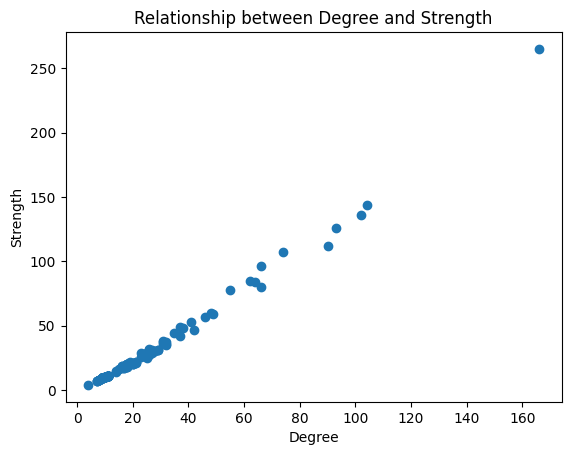

In [9]:
## YOUR CODE HERE
# Create scatter plot
plt.figure()
plt.scatter(metrics_df['Degree'],metrics_df['Strength'])
plt.xlabel('Degree')
plt.ylabel('Strength')
plt.title('Relationship between Degree and Strength')
plt.show()

## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 3.ipynb` to the following Staff Graded Assignment for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook 
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 3 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 3.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 3" by the deadline indicated within your course view for the Project 3 Assignment item.

Congratulations on completing the Project 3 Assignment!